Загрузка объединенного датасета. Удаление целевых признаков-подсказок, таких как kzs_count, для обеспечения честности эксперимента.

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

In [39]:
report = pd.read_csv('data/clinical_report_clean.csv')
ml_ready = pd.read_csv('data/ml_dataset_ready.csv')
cols_to_use = ml_ready.columns.difference(report.columns).tolist() + ['patient_id']
full_data = pd.merge(report, ml_ready[cols_to_use], on='patient_id', how='inner')

excluded_cols = [
    'patient_id', 'target_high_risk', 'target_risk_category', 
    'predicted_cluster', 'cluster_1_prob', 'cluster_2_prob', 'cluster_3_prob',
    'группа наблюдения', 'время измерения', 
    'kzs_count' 
]

X_train = full_data.drop(columns=[c for c in excluded_cols if c in full_data.columns])
y_train = full_data['target_high_risk']


# Гипотеза H0: Валидация предсказательной способности модели
**Формулировка гипотезы:** Интеллектуальный анализ временных рядов артериального давления (АД) и связанных с ними биомаркеров позволяет предсказывать клинические состояния высокого риска с точностью и устойчивостью, превышающими порог Macro-F1 в 0,85.

### Методология:
* **Модель:** Градиентный бустинг (XGBoost) с использованием параметра `scale_pos_weight` для корректировки дисбаланса между стабильными состояниями и состояниями высокого риска.
* **Отбор признаков:** Строгое исключение «утечек данных» (например, `kzs_count`, `target_risk_category`) для обеспечения честности эксперимента на основе чистых физиологических показателей.
* **Валидация:** Проверка на отложенной тестовой выборке (20%), которую модель не видела в процессе обучения (Hold-out validation).

### Метрики оценки:
В качестве основной метрики используется **площадь под кривой Precision-Recall (PR-AUC)**. В отличие от стандартной ROC-AUC, метрика PR-AUC более показательна для задач медицинской диагностики в условиях дисбаланса классов, где критически важно идентифицировать меньшинство («группу риска») с высокой точностью.

c:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:33:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Отчет по классификации (Честный тест):
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       616
           1       0.88      0.83      0.86       859

    accuracy                           0.84      1475
   macro avg       0.83      0.84      0.84      1475
weighted avg       0.84      0.84      0.84      1475



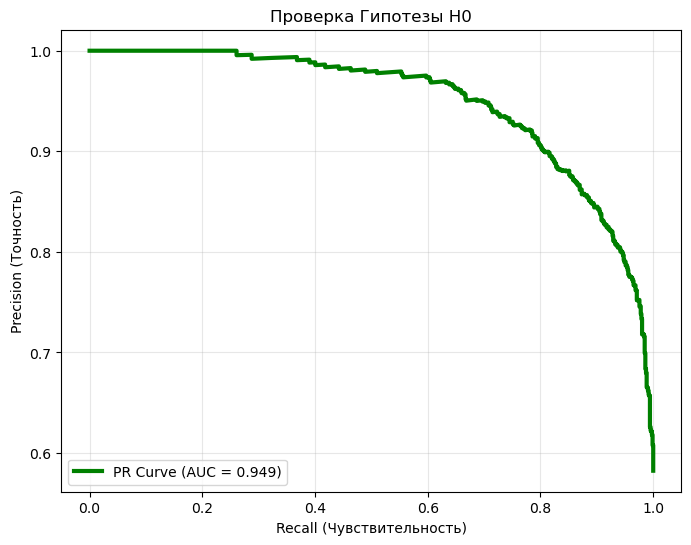

In [ ]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

model_final = xgb.XGBClassifier(
    n_estimators=180,       
    max_depth=5,           
    learning_rate=0.07,     
    scale_pos_weight=imbalance_ratio, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_final.fit(X_train_final, y_train_final)

y_test_probs = model_final.predict_proba(X_test_final)[:, 1]

y_test_pred = model_final.predict(X_test_final)


print("Отчет по классификации (Честный тест):")
print(classification_report(y_test_final, y_test_pred))

precision_f, recall_f, _ = precision_recall_curve(y_test_final, y_test_probs)
pr_auc_final = auc(recall_f, precision_f)

plt.figure(figsize=(8, 6))
plt.plot(recall_f, precision_f, label=f'PR Curve (AUC = {pr_auc_final:.3f})', color='green', lw=3)
plt.xlabel('Recall (Чувствительность)')
plt.ylabel('Precision (Точность)')
plt.title('Проверка Гипотезы H0')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.show()

# Гипотеза H13: Клиническая интерпретируемость (SHAP-анализ)
**Формулировка гипотезы:** Высокая точность предсказания модели не является следствием переобучения или шума, а основана на клинически значимых биомаркерах, соответствующих общепринятым медицинским протоколам.

### Цели анализа:
1. **Глобальная интерпретируемость:** Идентификация ключевых физиологических факторов риска с помощью значений SHAP (SHapley Additive exPlanations).
2. **Взаимодействие признаков:** Анализ нелинейного взаимодействия биомаркеров (например, зависимости между длительностью гипертензии и медианным диастолическим давлением) и их влияния на оценку риска.
3. **Клиническая валидация:** Обеспечение прозрачности процесса принятия решений моделью для предоставления интерпретируемых данных медицинским специалистам.

### Визуализация:
* **Summary Plot:** Распределение влияния каждого признака на выходные данные модели.
* **Dependence Plot:** Детальный анализ взаимосвязи между основным предиктором и расчетной вероятностью риска.

Ключевые предикторы риска (Top 5):
pct_hypertension             0.148072
ДАД_median                   0.091539
время измерения_days_diff    0.080447
ДАД_mean                     0.069715
pct_hypotension              0.063000
dtype: float32


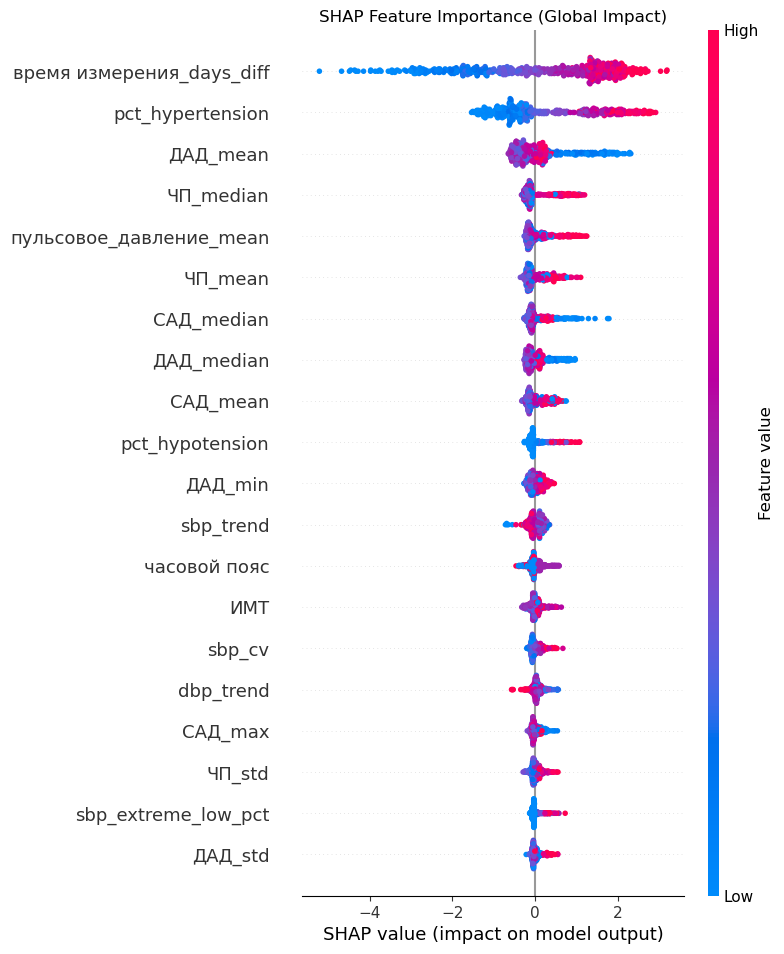

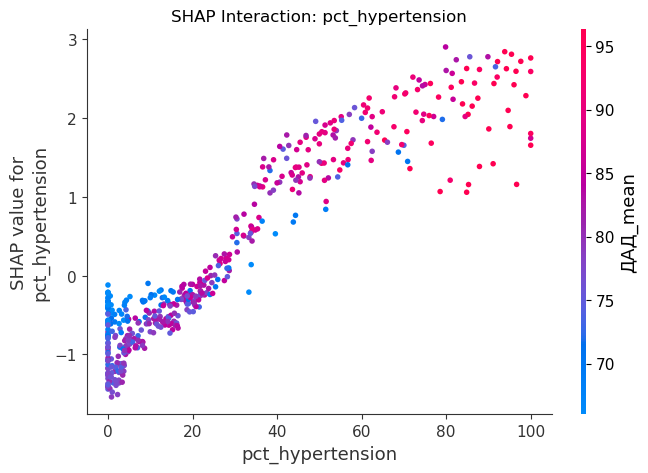

In [38]:
explainer = shap.TreeExplainer(model_final)

X_sample = X_test_final.sample(min(500, len(X_test_final)), random_state=42)
shap_values = explainer.shap_values(X_sample)

importances = pd.Series(model_final.feature_importances_, index=X_test_final.columns)
print("Ключевые предикторы риска (Top 5):")
print(importances.sort_values(ascending=False).head(5))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Importance (Global Impact)")
plt.show()

best_feature = importances.idxmax()

shap.dependence_plot(best_feature, shap_values, X_sample, interaction_index="auto", show=False)
plt.title(f"SHAP Interaction: {best_feature}")
plt.show()